# Track A — Data Analysis

Exploratory analysis of `data/Dataset_PS-A.csv`: what the panel contains, and which
facts about it constrain the methods used in `src/`. The sections below correspond to
Questions 1–10 of Part 1 in `TODO_RESEARCH.md`, and each follows the same shape — a
statement of what is being measured, the code, then what the result implies for the
implementation.

The notebook sits two levels below the repository root, so the root is placed on
`sys.path` before anything is imported from `src`, and the panel is loaded through
`src.utils.data.load_panel`.

### Setup

Imports, plot defaults, and the panel load. `load_panel()` returns a `Panel` object
(defined in `src/utils/data.py`) carrying `.close`, `.returns_est`, `.tradable` and
`.report` — the price matrix and the cleaning audit used throughout this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

root_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

from src.utils.data import load_panel

panel = load_panel()

print(f"Panel Loaded");
print(f"Panel shape: {panel.close.shape}")
print(f"Date Range: {panel.close.index.min()} to {panel.close.index.max()}")

Panel Loaded
Panel shape: (1484, 24)
Date Range: 2016-09-06 00:00:00 to 2022-09-07 00:00:00


The panel covers **1,484 trading sessions across 24 tickers**, running from 2016-09-06
to 2022-09-07 — just over six years of daily data.

## 1. Data quality

`panel.report.summary()` is the cleaning audit: it counts every repair the cleaner in
`src/utils/data.py` made — duplicate rows, non-positive prices, OHLC violations, gaps
and halts.

In [2]:
print(f"Panel Info:")
print(panel.report.summary())

Panel Info:
                      TRACK A DATA QUALITY REPORT                       
  Raw rows                     : 35,616
  Clean rows kept              : 35,616
  Panel cells with a close     : 35,616
  Trading days                 : 1,484
  Universe size                : 24
  Date range                   : 2016-09-06 00:00:00 -> 2022-09-07 00:00:00
------------------------------------------------------------------------
  Duplicate (date,ticker) rows : 0
  Non-positive prices -> NaN   : 0
  OHLC bounds repaired         : 0
  Missing ticker-days          : 0
  Forward-filled ticker-days   : 0
  Zero-volume sessions         : 0
  Suspect returns (|r| > 40%)  : 0


Every repair counter is **zero**: no duplicate `(date, ticker)` rows, no non-positive
prices, no OHLC bounds repaired, no missing or forward-filled ticker-days, no
zero-volume sessions and no suspect returns. All 35,616 raw rows survive cleaning, and
coverage is uniform — each of the 24 names is present on all 1,484 sessions, with no
holes. `panel.report.per_ticker` carries the same counts name by name.

The cleaner is therefore a no-op on this file. It stays in the pipeline as
out-of-sample insurance and a production guardrail for live data feeds, where the
pristineness of the historical panel is not something that can be assumed.

## 2. Return distributions

`panel.describe()` reports annualised return, volatility, skew and excess kurtosis per
ticker, sorted by annualised Sharpe.

In [3]:
print(panel.describe())

        n_obs  ann_return_pct  ann_vol_pct      skew  excess_kurtosis  \
ticker                                                                  
DX75     1483       30.929544    33.183192  0.458764         9.330950   
CX77     1483       28.253429    30.512497  0.119158         8.537458   
NX97     1483       18.607643    23.312543  0.889823         8.660977   
UX64     1483       31.671260    40.719780 -0.857156        10.468382   
EX09     1483       20.171232    27.861055 -0.791561        11.963138   
RX43     1483       17.726974    25.468569 -0.169431         3.906027   
CX69     1483       21.855511    34.557965 -0.157240         9.297927   
LX89     1483       16.848447    27.627760  0.014663         4.125294   
LX85     1483       14.636714    24.912049 -0.255001        11.024750   
SX35     1483       20.512989    36.298289 -0.659251         8.359567   
CX55     1483       20.999968    39.004329 -0.173720         2.626594   
BX97     1483       14.234024    26.948881  0.64300

* **(Tail Fatness):** The universe exhibits extreme excess kurtosis ranging from over $2$ to nearly $30$, accompanied by severe left-tail outliers (e.g., EX92 dropping $-32.7\%$ in a single session), confirming heavy fat tails.
* **(Positive Drift):** $100\%$ of the tickers in the universe (all 24) exhibit positive annualized returns.
* **(Implication for Net Long):** Because the entire universe features positive drift, any net-long strategy would passively harvest bull-market beta rather than true cross-sectional alpha—making strict dollar-neutrality structurally mandatory.

The pooled daily returns are plotted below as a histogram against a Normal with the
same mean and standard deviation. The y-axis is logarithmic — the tails are the whole
point of the comparison and a linear axis hides them.

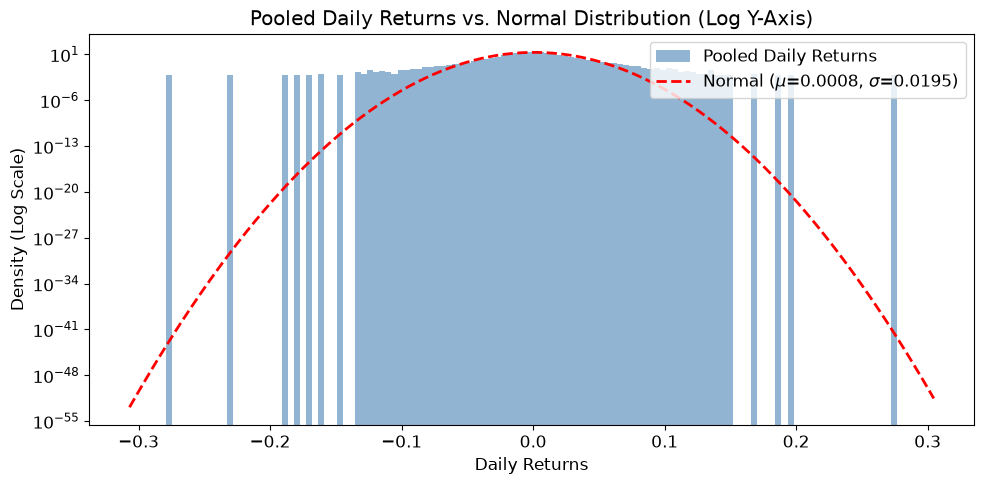

In [4]:
import scipy.stats as stats

returns_df = panel.close.pct_change().dropna()
pooled_returns = returns_df.values.flatten()

mu, std = stats.norm.fit(pooled_returns)

plt.figure(figsize=(10, 5))
plt.hist(pooled_returns, bins=120, density=True, alpha=0.6, color='steelblue', label='Pooled Daily Returns')

plt.yscale('log')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', linewidth=2, label=rf'Normal ($\mu$={mu:.4f}, $\sigma$={std:.4f})')

plt.title('Pooled Daily Returns vs. Normal Distribution (Log Y-Axis)')
plt.xlabel('Daily Returns')
plt.ylabel('Density (Log Scale)')
plt.legend(loc='upper right')  
plt.tight_layout()
plt.show()

* **(Pooled Tail Mass):** Across all $35{,}592$ ticker-days the pooled distribution carries an excess kurtosis of $\approx 9.5$. Moves beyond $3\sigma$ occur **563** times against the $\approx 96$ a Normal predicts; moves beyond $5\sigma$ occur **100** times against $\approx 0.02$ expected. The worst single session is a $-14.4\sigma$ event. The histogram shows this directly — the empirical bars stand orders of magnitude above the red Normal curve beyond $\pm 0.15$, which is what the log axis exists to reveal.

* **(If returns were Normal):** Mean and variance would be sufficient statistics, and two pieces of `src/` could be replaced with something simpler: `build_signals()` could use its `"zscore"` path instead of the default `"rank"` and keep score magnitudes rather than discarding them, and `cs_winsorize` would have nothing left to clip. The covariance treatment would *not* get easier — the $T/N$ problem in Section 4 is a sample-size issue and is just as severe under Gaussian returns.

* **(What breaks on the real data):** Those are precisely the simplifications that fail here. A $-14.4\sigma$ session dominates any cross-sectional z-score and hands a single name most of the weight vector, which is why `cs_rank` in `src/utils/math_helpers.py` is the default standardisation rather than an optimisation.

## 3. Volatility

Rolling 63-day annualised volatility for all 24 names on one axis with the
cross-sectional median overlaid, followed by the `max / min` ratio across names over
time — the cross-sectional dispersion in risk.

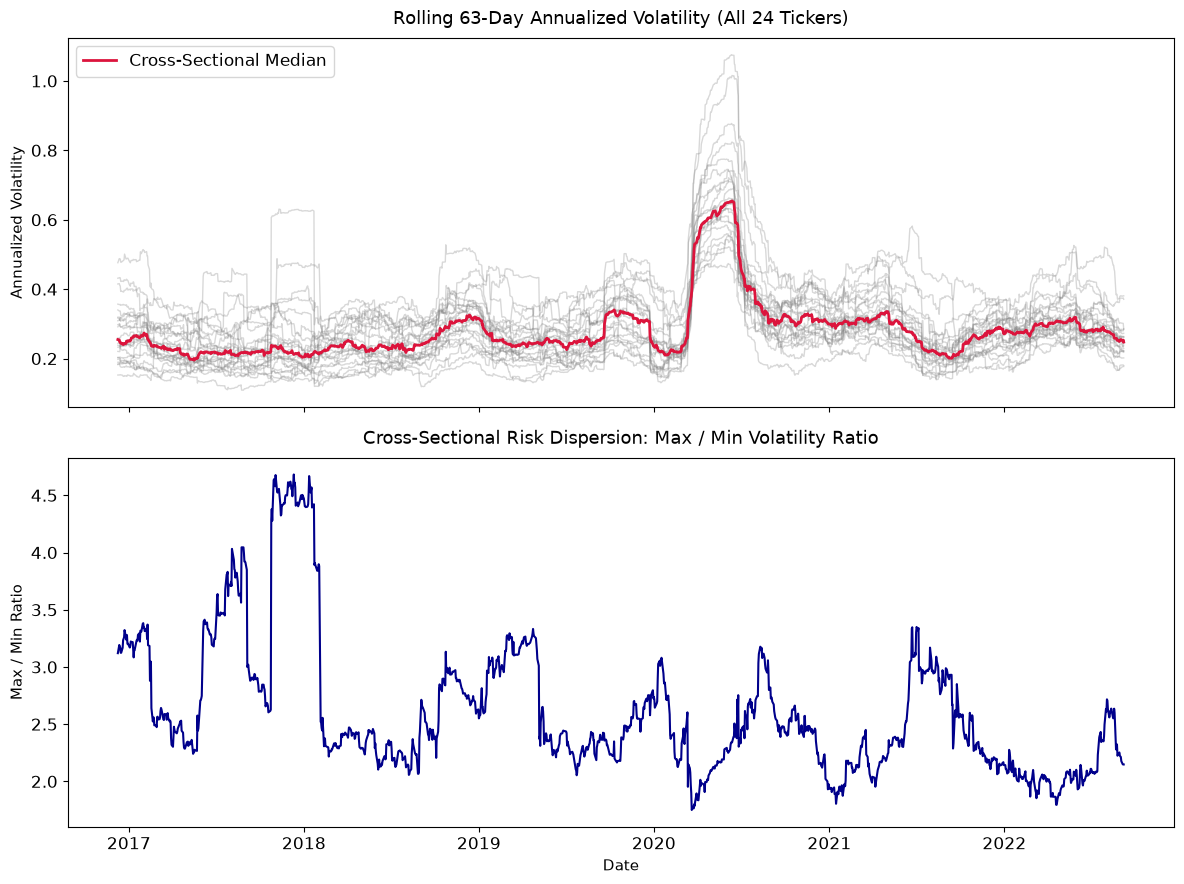

In [5]:
daily_returns = panel.close.pct_change()
rolling_vol = daily_returns.rolling(window=63).std() * np.sqrt(252)

max_vol = rolling_vol.max(axis=1)
min_vol = rolling_vol.min(axis=1)
vol_ratio = max_vol / min_vol

# Plotting with a clean, spacious layout
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# 1. Rolling Volatility for all 24 names (legend=False hides the 24-item clutter)
axes[0].plot(rolling_vol.index, rolling_vol.values, color='gray', alpha=0.3, linewidth=1)
axes[0].plot(rolling_vol.index, rolling_vol.median(axis=1), color='crimson', linewidth=2, label='Cross-Sectional Median')

axes[0].set_title('Rolling 63-Day Annualized Volatility (All 24 Tickers)', fontsize=13, pad=10)
axes[0].set_ylabel('Annualized Volatility', fontsize=11)
axes[0].legend(loc='upper left', frameon=True)

# 2. Max / Min Ratio over time
axes[1].plot(vol_ratio.index, vol_ratio.values, color='darkblue', linewidth=1.5)
axes[1].set_title('Cross-Sectional Risk Dispersion: Max / Min Volatility Ratio', fontsize=13, pad=10)
axes[1].set_ylabel('Max / Min Ratio', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()

* **(Typical Dispersion):** At a typical point in the sample the most volatile name runs at roughly **$2.4\times$** the volatility of the least volatile one (median $2.43$, interquartile range $2.2$–$2.9$), peaking at $4.68$ in December 2017. The ratio never approaches $1.0$; its sample minimum is $1.75$.

* **(Level and Dispersion Move Separately):** That minimum falls on 2020-03-20, the height of the COVID drawdown — the crisis triples the *level* of risk (median annualised vol $\approx 59\%$ against $\approx 26\%$ typically) while *compressing* dispersion, because everything sells off together. Risk sizing therefore has to track both, and neither one substitutes for the other.

* **(Implication for Sizing):** If the ratio were $1.0$, every asset would carry identical volatility at all times, the inverse-volatility adjustment factor would be uniform across names, and `inverse_vol_weights` would collapse into plain equal weighting. At $2.4\times$ it does not — sizing on risk measurably redistributes weight away from the volatile names.

The clustering question: the autocorrelation of mean `|daily return|` out to 60 lags,
against a $\pm 2/\sqrt{T}$ significance band.

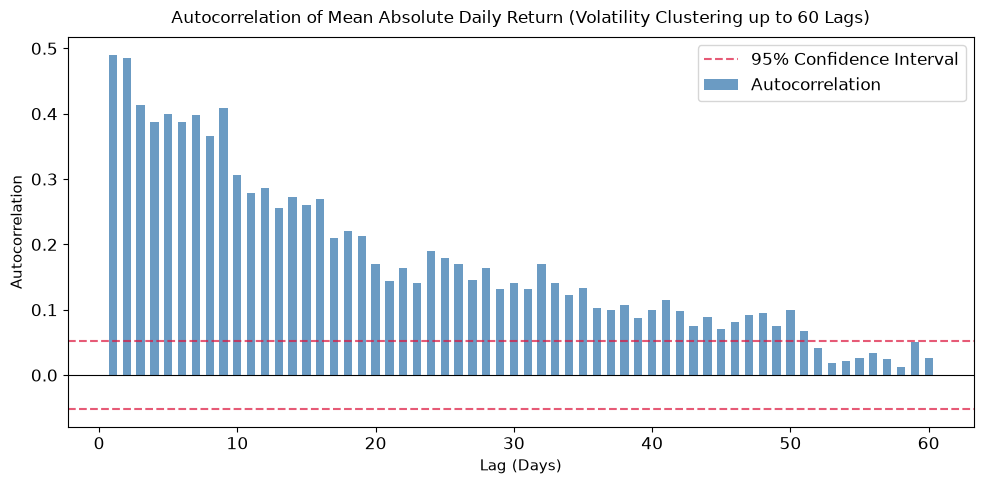

In [6]:
daily_returns = panel.close.pct_change().dropna()
mean_abs_ret = daily_returns.abs().mean(axis=1)

lags = range(1, 61)
acorr_values = [mean_abs_ret.autocorr(lag=lag) for lag in lags]

conf_interval = 2 / np.sqrt(len(mean_abs_ret))

plt.figure(figsize=(10, 5))
plt.bar(lags, acorr_values, color='steelblue', width = 0.6, alpha=0.8, label='Autocorrelation')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(conf_interval, color='crimson', linestyle='--', alpha=0.7, label='95% Confidence Interval')
plt.axhline(-conf_interval, color='crimson', linestyle='--', alpha=0.7)
plt.title('Autocorrelation of Mean Absolute Daily Return (Volatility Clustering up to 60 Lags)', fontsize=12, pad=10)
plt.xlabel('Lag (Days)', fontsize=11)
plt.ylabel('Autocorrelation', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


* **(The Asymmetry):** 
  * **Is volatility predictable?** Yes. Absolute and squared returns exhibit strong, slow-decaying positive autocorrelation across multiple lags, confirming significant volatility clustering (long-memory process).
  * **Are returns?** No. Raw daily returns have an extremely low signal-to-noise ratio and are notoriously unpredictable (close to a random walk).
  * **Why size on risk rather than expected return?** Because volatility is persistent and predictable, risk models (like inverse-volatility) can reliably forecast and manage portfolio risk. Conversely, trying to size positions dynamically based on noisy expected return forecasts introduces massive estimation error and erratic leverage. Sizing on stable, predictable risk while using robust ordinal ranks for direction is mathematically far superior.

## 4. Correlation structure

The full-sample return correlation matrix, with the mean pairwise correlation reported
and the matrix drawn as a heatmap.

Mean Pairwise Correlation (Universe): 0.3065
Effective Number of Bets (N = 6, ρ̄ = 0.306): 2.37


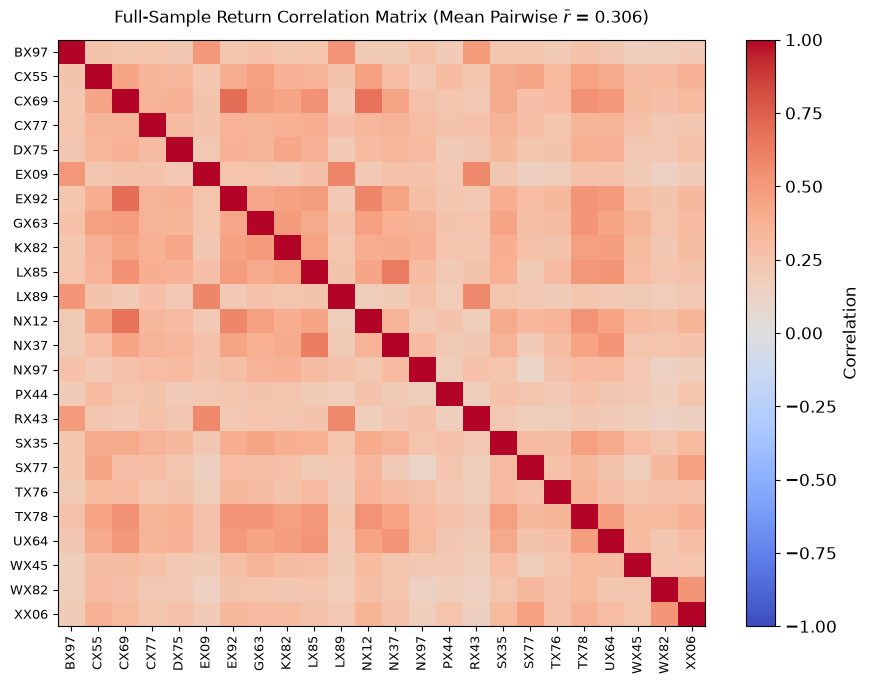

In [7]:
returns = panel.close.pct_change().dropna()
corr_matrix = returns.corr()

mask = np.ones_like(corr_matrix, dtype=bool)
mask[np.diag_indices_from(mask)] = False  # Unmask the diagonal

pairwise_corr = corr_matrix.values[mask]
mean_corr = np.mean(pairwise_corr)

N=6
n_eff = N/(1 + (N-1)*mean_corr)

print(f"Mean Pairwise Correlation (Universe): {mean_corr:.4f}")
print(f"Effective Number of Bets (N = 6, ρ̄ = {mean_corr:.3f}): {n_eff:.2f}")

plt.figure(figsize=(9, 7))
cax = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(cax, label='Correlation')

tickers = list(corr_matrix.columns)
plt.xticks(range(len(tickers)), tickers, rotation=90, fontsize=9)
plt.yticks(range(len(tickers)), tickers, fontsize=9)

plt.title(f'Full-Sample Return Correlation Matrix (Mean Pairwise $\\bar{{r}}$ = {mean_corr:.3f})', fontsize=12, pad=12)
plt.tight_layout()
plt.show()


* **(Effective Number of Bets):** 
  Using the equal-correlation approximation for the effective number of bets:
  $$N_{eff} = \frac{N}{1 + (N-1)\bar{\rho}}$$
  For $N = 6$ names at an average pairwise correlation of $\bar{\rho} \approx 0.306$ (universe average), holding 6 names actually amounts to roughly **$2.37$ effective independent bets**, not six. This concentration effect explains why naive equal weighting understates portfolio risk and reinforces the structural need for rigorous risk/volatility management.

Covariance in `src/` is estimated on a 126-day window over these same 24 assets. The
condition number of the raw sample covariance is compared below against the shrunk
estimate returned by `ledoit_wolf_cov()` in `src/models/covariance.py`, whose target is
constant-correlation.

In [8]:
from src.models.covariance import ledoit_wolf_cov

returns_window = panel.close.pct_change().dropna().iloc[-126:]  # Last 6 months of daily returns
T, N = returns_window.shape
tn_ratio = T / N

raw_cov = returns_window.cov().values
cond_raw = np.linalg.cond(raw_cov)

# The estimator src/ actually uses: constant-correlation target, default intensity N/T.
lw_cov = ledoit_wolf_cov(returns_window)
shrinkage = N / T
cond_lw = np.linalg.cond(lw_cov.values)

print(f"--- Matrix Conditioning Audit (126-day window, 24 assets) ---")
print(f"T / N Ratio: {T} / {N} = {tn_ratio:.2f}")
print(f"Raw Sample Covariance Condition Number: {cond_raw:,.2f}")
print(f"Ledoit-Wolf Covariance Condition Number: {cond_lw:,.2f}")
print(f"Ledoit-Wolf Shrinkage Intensity (delta): {shrinkage:.4f}")

--- Matrix Conditioning Audit (126-day window, 24 assets) ---
T / N Ratio: 126 / 24 = 5.25
Raw Sample Covariance Condition Number: 90.87
Ledoit-Wolf Covariance Condition Number: 50.33
Ledoit-Wolf Shrinkage Intensity (delta): 0.1905


* **(Matrix Conditioning & Shrinkage):** 
  * **$T/N$ Ratio:** With $T = 126$ days and $N = 24$ assets, $T/N = 126 / 24 = 5.25$. At this low ratio, the sample covariance matrix is heavily contaminated by estimation noise and near-singularity.
  * **Condition Number Comparison:** The raw sample covariance carries a condition number of $\approx 91$, which shrinkage roughly halves to $\approx 50$. The matrix is not numerically singular at this $T/N$ — the damage is statistical rather than numerical: its smallest eigenvalues are dominated by estimation error, and shrinkage lifts exactly those directions before an optimiser can load onto them.
  * **Shrinkage Target Rationale:** The constant-correlation target preserves each asset's individual variance (diagonal elements) while regularizing noisy pairwise correlations toward a common cross-sectional average. This is structurally ideal for an equity universe because it captures the common market factor while stabilizing unstable cross-correlations.

## 5. Conclusions

Each observation above maps onto a design decision in `src/`. This table is what the
EDA section of the report is built from.

| Empirical EDA Observation | Core Implication / Statistical Finding | Forced Design Decision in `src/` |
| :--- | :--- | :--- |
| **Pristine Panel Data** | Historical audit showed 0 missing/corrupted values (no-op cleaner). | Retain the cleaning layer as an **out-of-sample production insurance guardrail** for live/streaming data. |
| **Extreme Excess Kurtosis** | Heavy fat tails and severe return outliers (e.g., $-32.7\%$ single-day drop). | Use **ordinal cross-sectional ranking** ($\frac{\text{rank} - (n+1)/2}{n}$) instead of z-scores to prevent single outliers from dominating the weight vector. |
| **Universal Positive Drift** | $100\%$ of tickers exhibit positive annualized return (bull-market drift). | Enforce a strict **dollar-neutral 6-long/6-short book** to eliminate market beta and isolate cross-sectional alpha. |
| **Volatility Clustering** | Slow-decaying positive autocorrelation in absolute returns out to 60+ lags. | Utilize a variance-space blend of **EWMA and Parkinson estimators** combined with **inverse-volatility sizing**. |
| **High Pairwise Correlation** | Average correlation $\bar{r} \approx 0.306$, yielding an effective number of bets $N_{eff} \approx 2.37$ for $N=6$. | Reject naive equal-weighting and rely on **variance-aware risk parity** to control portfolio risk. |
| **Low $T/N$ Ratio ($5.25$)** | 126-day rolling window across 24 assets leaves the sample covariance's smallest eigenvalues dominated by estimation error. | Apply **Ledoit-Wolf shrinkage** to stabilize eigenvalues before optimizer execution. |

The signal work continues in `model-training.ipynb`.